# Taller — Abandono de producto financiero

**Regresión logística en Python**  
**Curso:** Machine Learning aplicado a Economía y Finanzas  
**Estudiante:** Martin Galeano

## Punto 0 — Preparación

El archivo `abandono_producto_financiero.csv` se conserva en la raíz del repositorio. Se usa una ruta relativa para que el cuaderno pueda ejecutarse desde otra copia del proyecto sin cambiar rutas locales.

## Sección 1 — Estructura de los datos

### Importación de librerías y carga de la base

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

RUTA_DATOS = "abandono_producto_financiero.csv"
datos_crudos = pd.read_csv(RUTA_DATOS)

### Primeras observaciones

In [2]:
datos_crudos.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


### Columnas y dimensión de la base cruda

In [3]:
print("Columnas de la base cruda:")
print(datos_crudos.columns.tolist())
print()
print("Dimensión de la base cruda:", datos_crudos.shape)

Columnas de la base cruda:
['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']

Dimensión de la base cruda: (10000, 14)


### Tipos asignados por pandas

In [4]:
datos_crudos.dtypes

numero_fila             int64
id_cliente              int64
apellido               object
puntaje_crediticio      int64
pais                   object
sexo                   object
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

### Estadísticas descriptivas de la base cruda

In [5]:
datos_crudos.describe().T

,count,mean,std,min,25%,50%,75%,max
numero_fila,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
id_cliente,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
puntaje_crediticio,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
edad,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
antiguedad,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
saldo,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
numero_productos,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
tiene_tarjeta,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
miembro_activo,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
salario_estimado,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


### Preparación del DataFrame de modelación

Según el enunciado, `numero_fila`, `id_cliente` y `apellido` son identificadores y no deben entrar en la fórmula del modelo.

In [6]:
columnas_identificadoras = ["numero_fila", "id_cliente", "apellido"]
datos = datos_crudos.drop(columns=columnas_identificadoras).copy()

# El orden fija las categorías de referencia requeridas por el profesor.
datos["pais"] = pd.Categorical(
    datos["pais"],
    categories=["Francia", "Alemania", "España"]
)
datos["sexo"] = pd.Categorical(
    datos["sexo"],
    categories=["Mujer", "Hombre"]
)

# La respuesta se conserva como variable binaria entera.
datos["abandono"] = datos["abandono"].astype("int64")

### Verificación de la estructura preparada

In [7]:
print("Dimensión para modelación:", datos.shape)
print()
print("Columnas para modelación:")
print(datos.columns.tolist())
print()
print("Tipos finales:")
print(datos.dtypes)
print()
print("Niveles de pais:", datos["pais"].cat.categories.tolist())
print("Niveles de sexo:", datos["sexo"].cat.categories.tolist())
print("Valores de abandono:", sorted(datos["abandono"].unique().tolist()))

Dimensión para modelación: (10000, 11)

Columnas para modelación:
['puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']

Tipos finales:
puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

Niveles de pais: ['Francia', 'Alemania', 'España']
Niveles de sexo: ['Mujer', 'Hombre']
Valores de abandono: [0, 1]


### Clasificación y conteo de variables

In [8]:
variables_cuantitativas = [
    "puntaje_crediticio",
    "edad",
    "antiguedad",
    "saldo",
    "numero_productos",
    "salario_estimado",
]

variables_categoricas = ["pais", "sexo"]
variables_binarias = ["tiene_tarjeta", "miembro_activo", "abandono"]

clasificacion_variables = pd.DataFrame({
    "grupo": ["Cuantitativas", "Categóricas", "Binarias"],
    "cantidad": [
        len(variables_cuantitativas),
        len(variables_categoricas),
        len(variables_binarias),
    ],
    "variables": [
        ", ".join(variables_cuantitativas),
        ", ".join(variables_categoricas),
        ", ".join(variables_binarias),
    ],
})

clasificacion_variables

,grupo,cantidad,variables
0,Cuantitativas,6,"puntaje_crediticio, edad, antiguedad, saldo, n..."
1,Categóricas,2,"pais, sexo"
2,Binarias,3,"tiene_tarjeta, miembro_activo, abandono"


### Pregunta 1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?

La base cruda tiene **14 variables**. Después de retirar `numero_fila`, `id_cliente` y `apellido`, el DataFrame de modelación queda con **11 variables**: diez explicativas y la variable respuesta `abandono`.

### Pregunta 2. ¿Cuántas son cuantitativas?

De acuerdo con el diccionario del enunciado, hay **6 variables cuantitativas**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y `salario_estimado`. Aunque `numero_productos` toma valores enteros, el profesor la incluye entre las variables numéricas de modelación.

### Pregunta 3. ¿Cuántas son categóricas o binarias, incluyendo abandono?

Hay **2 variables categóricas** (`pais` y `sexo`) y **3 variables binarias** (`tiene_tarjeta`, `miembro_activo` y `abandono`). En conjunto son **5 variables categóricas o binarias**, incluyendo la respuesta.

### Pregunta 4. ¿Qué implica esta mezcla para el logit en Python?

Las variables cuantitativas y las binarias 0/1 pueden entrar directamente en la fórmula. En cambio, `pais` y `sexo` representan grupos sin una distancia numérica entre sus niveles. Al escribir `C(pais)` y `C(sexo)` en una fórmula de `statsmodels`, Python crea internamente los indicadores necesarios y deja una categoría como referencia, evitando incluir todas las dummies al mismo tiempo. Como los niveles fueron ordenados según el enunciado, las referencias serán **Francia** para país y **Mujer** para sexo. Esto permite interpretar los coeficientes de las demás categorías como comparaciones frente a esas referencias, sin construir las dummies manualmente.

## Sección 2 — Descriptivo univariado

### Distribución de la variable `abandono`

In [9]:
conteos_abandono = datos["abandono"].value_counts().sort_index()
proporciones_abandono = datos["abandono"].value_counts(normalize=True).sort_index()

tabla_abandono = pd.DataFrame({
    "estado": ["Permanece", "Abandona"],
    "conteo": conteos_abandono,
    "proporcion": proporciones_abandono,
    "porcentaje": proporciones_abandono * 100,
})
tabla_abandono.index.name = "abandono"
tabla_abandono.round({"proporcion": 4, "porcentaje": 2})

,estado,conteo,proporcion,porcentaje
abandono,,,,
0,Permanece,7963,0.7963,79.63
1,Abandona,2037,0.2037,20.37


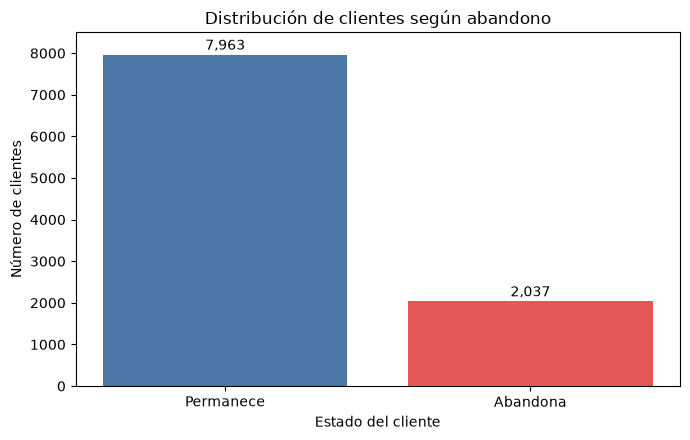

In [10]:
plt.figure(figsize=(7, 4.5))
plt.bar(
    tabla_abandono["estado"],
    tabla_abandono["conteo"],
    color=["#4C78A8", "#E45756"]
)
plt.title("Distribución de clientes según abandono")
plt.xlabel("Estado del cliente")
plt.ylabel("Número de clientes")
plt.ylim(0, 8500)
for posicion, valor in enumerate(tabla_abandono["conteo"]):
    plt.text(posicion, valor + 120, f"{valor:,}", ha="center")
plt.tight_layout()
plt.show()

### Estadísticas descriptivas de las variables cuantitativas

In [11]:
columnas_descriptivas = [
    "puntaje_crediticio",
    "edad",
    "antiguedad",
    "saldo",
    "numero_productos",
    "salario_estimado",
]
datos[columnas_descriptivas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


### Histogramas

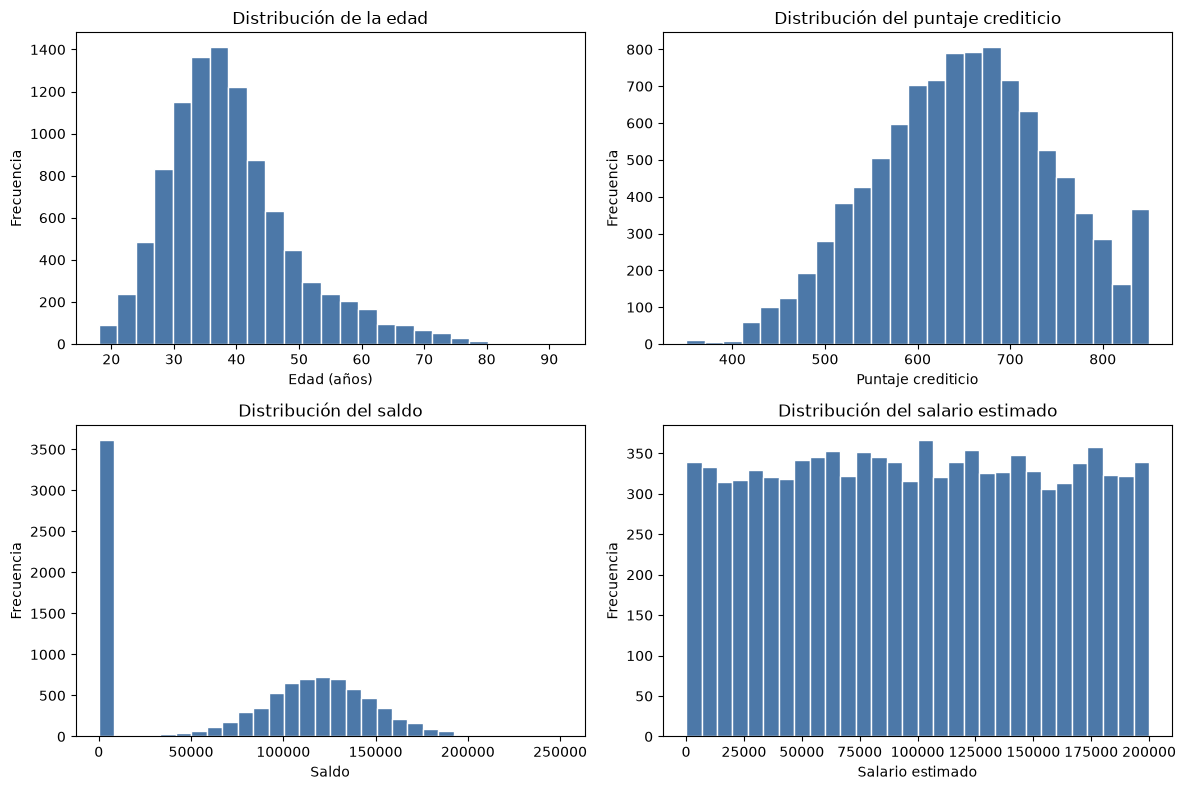

In [12]:
variables_histograma = {
    "edad": ("Distribución de la edad", "Edad (años)", 25),
    "puntaje_crediticio": ("Distribución del puntaje crediticio", "Puntaje crediticio", 25),
    "saldo": ("Distribución del saldo", "Saldo", 30),
    "salario_estimado": ("Distribución del salario estimado", "Salario estimado", 30),
}

fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
for eje, (variable, (titulo, etiqueta_x, bins)) in zip(ejes.ravel(), variables_histograma.items()):
    eje.hist(datos[variable], bins=bins, color="#4C78A8", edgecolor="white")
    eje.set_title(titulo)
    eje.set_xlabel(etiqueta_x)
    eje.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Frecuencias de variables categóricas y discretas

In [13]:
from IPython.display import display

tablas_frecuencias = {}
for variable in ["pais", "sexo", "numero_productos", "miembro_activo"]:
    conteo = datos[variable].value_counts(sort=False)
    proporcion = datos[variable].value_counts(normalize=True, sort=False)
    tabla = pd.DataFrame({
        "conteo": conteo,
        "proporcion": proporcion,
        "porcentaje": proporcion * 100,
    })
    tablas_frecuencias[variable] = tabla
    print(f"Frecuencias de {variable}")
    display(tabla.round({"proporcion": 4, "porcentaje": 2}))

Frecuencias de pais


,conteo,proporcion,porcentaje
pais,,,
Francia,5014,0.5014,50.14
Alemania,2509,0.2509,25.09
España,2477,0.2477,24.77


Frecuencias de sexo


,conteo,proporcion,porcentaje
sexo,,,
Mujer,4543,0.4543,45.43
Hombre,5457,0.5457,54.57


Frecuencias de numero_productos


,conteo,proporcion,porcentaje
numero_productos,,,
1,5084,0.5084,50.84
3,266,0.0266,2.66
2,4590,0.4590,45.90
4,60,0.0060,0.60


Frecuencias de miembro_activo


,conteo,proporcion,porcentaje
miembro_activo,,,
1,5151,0.5151,51.51
0,4849,0.4849,48.49


### Pregunta 5. ¿Qué porcentaje abandonó y por qué la exactitud puede ser engañosa?

El **20,37%** de los clientes abandonó el banco, mientras que el **79,63%** permaneció. Esta diferencia entre las clases hace que la exactitud, por sí sola, pueda dar una impresión equivocada del desempeño. Un clasificador que siempre predijera “permanece” obtendría una exactitud de 79,63%, pero no identificaría a ningún cliente que realmente abandona. Por eso, más adelante será necesario complementar la exactitud con medidas como la sensibilidad de la clase abandono y revisar la matriz de confusión.